In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
DATA_PATH = Path('../data/climate_change_impact_on_agriculture_2024.csv')
df = pd.read_csv(DATA_PATH)
df["Decade"] = (df["Year"] // 10) * 10

# CA-relevant crops
CA_CROPS = ["Wheat", "Cotton", "Rice", "Barley"]
ca_df = df[df["Crop_Type"].isin(CA_CROPS)].copy()

# Professional style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print(f"Full dataset: {df.shape}")
print(f"CA crops subset: {ca_df.shape}")

Full dataset: (10000, 16)
CA crops subset: (4065, 16)


Chart 1 — Crop yield distribution by crop type
Type: Boxplot
X: Crop_Type
Y: Crop_Yield_MT_per_HA
Color: by crop type

All crops have nearly identical yield distributions (median ~2.2 MT/ha) — suggesting the dataset is synthetic

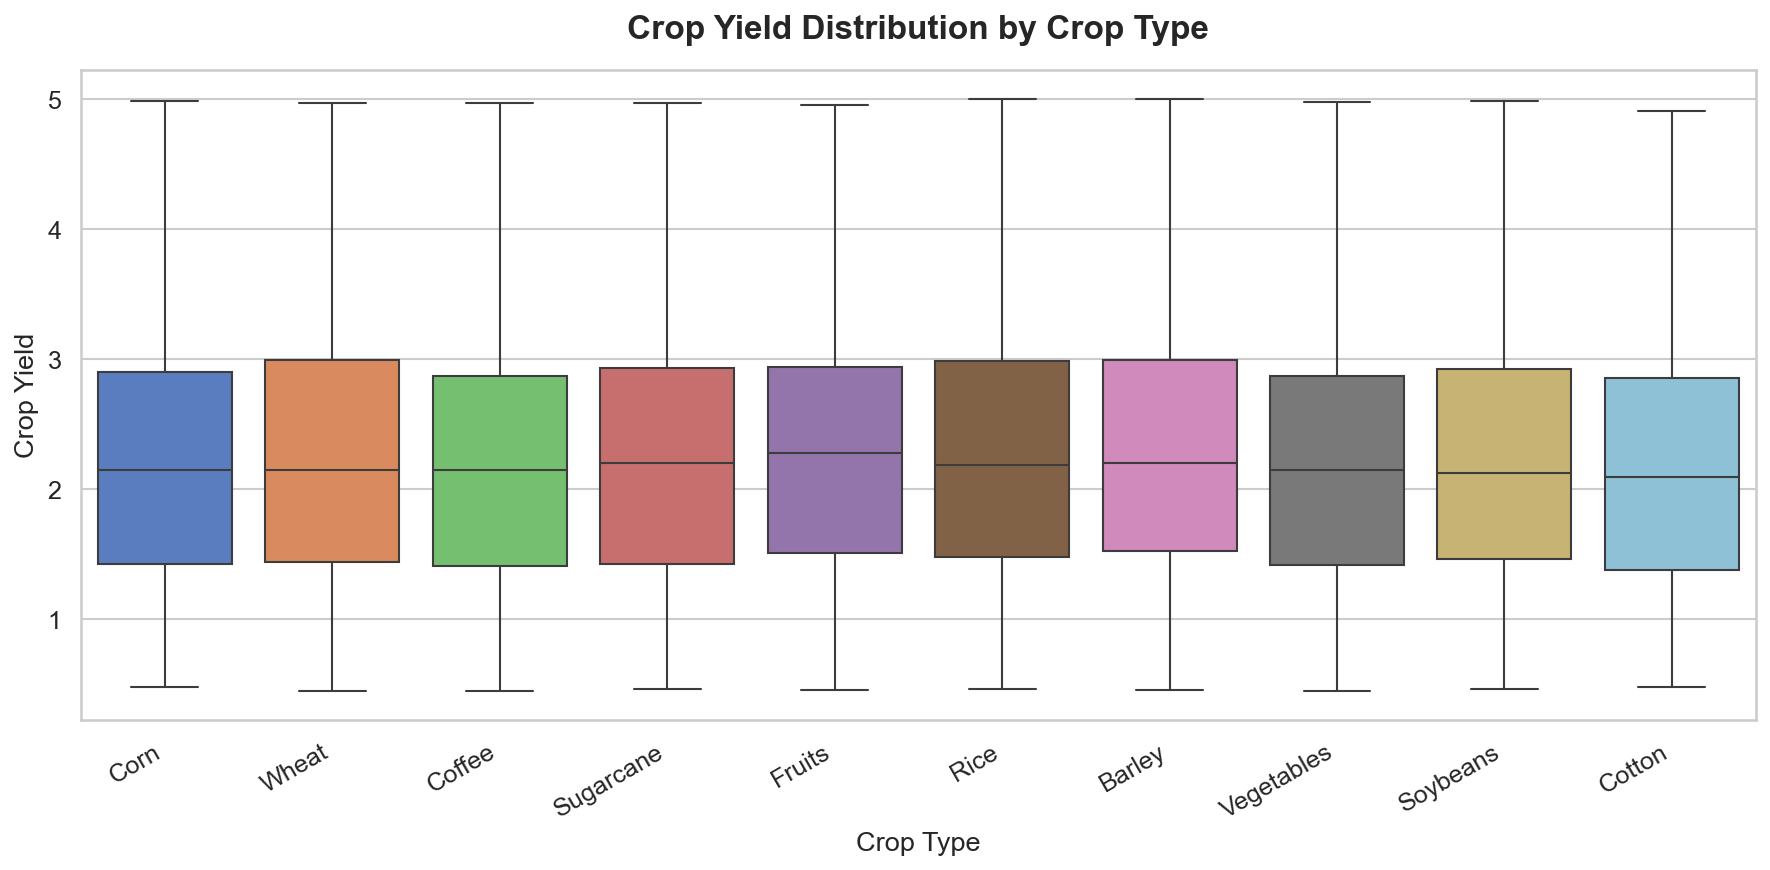

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="Crop_Type", 
    y="Crop_Yield_MT_per_HA", 
    palette="muted",
    hue="Crop_Type",
    ax=ax)
ax.set_title("Crop Yield Distribution by Crop Type", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Crop Type", fontsize=13)
ax.set_ylabel("Crop Yield", fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../outputs/charts/01_yield_by_crop.png", dpi=150)
plt.show()

Chart 2 — Temperature vs Crop yield scatter
Type: Scatter
X: Average_Temperature_C
Y: Crop_Yield_MT_per_HA
Color: by Crop_Typea

Weak positive trend — higher temperatures slightly associated with higher yield.

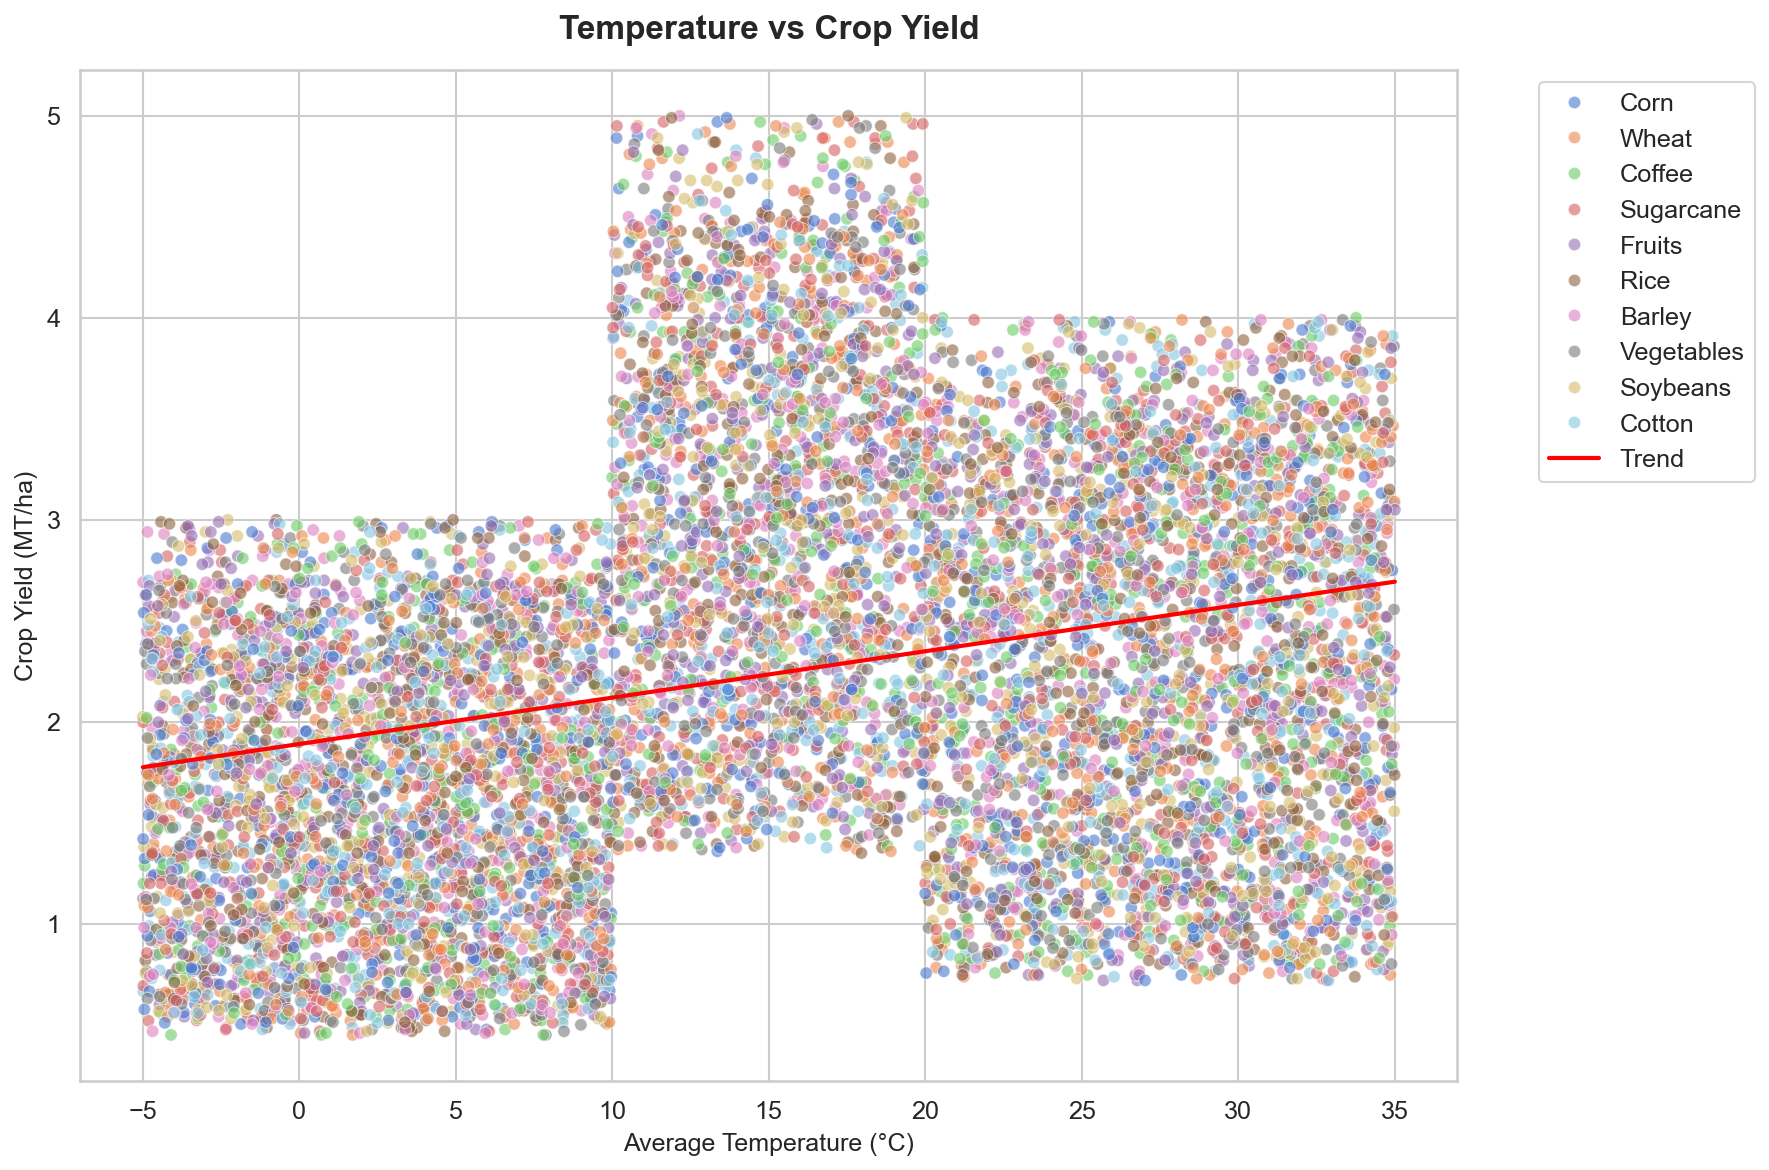

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="Average_Temperature_C", 
    y="Crop_Yield_MT_per_HA",
    hue="Crop_Type",
    alpha=0.6,
    edgecolor='white',
    ax=ax
    )
ax.set_title("Temperature vs Crop Yield", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Average Temperature (°C)", fontsize=12)
ax.set_ylabel("Crop Yield (MT/ha)", fontsize=12)
#trend line
z = np.polyfit(df["Average_Temperature_C"], df["Crop_Yield_MT_per_HA"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["Average_Temperature_C"].min(),
                    df["Average_Temperature_C"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=2, label="Trend")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout()
plt.savefig("../outputs/charts/02_temp_vs_yield.png", dpi=150, bbox_inches="tight")
plt.show()

Chart 3 — Average yield per decade — line chart
Type: Line chart
X: Decade
Y: mean Crop_Yield_MT_per_HA
Separated line per Crop_Type

No crop shows strong yield improvement over 30 years — all lines stay flat around 2.2 MT/ha

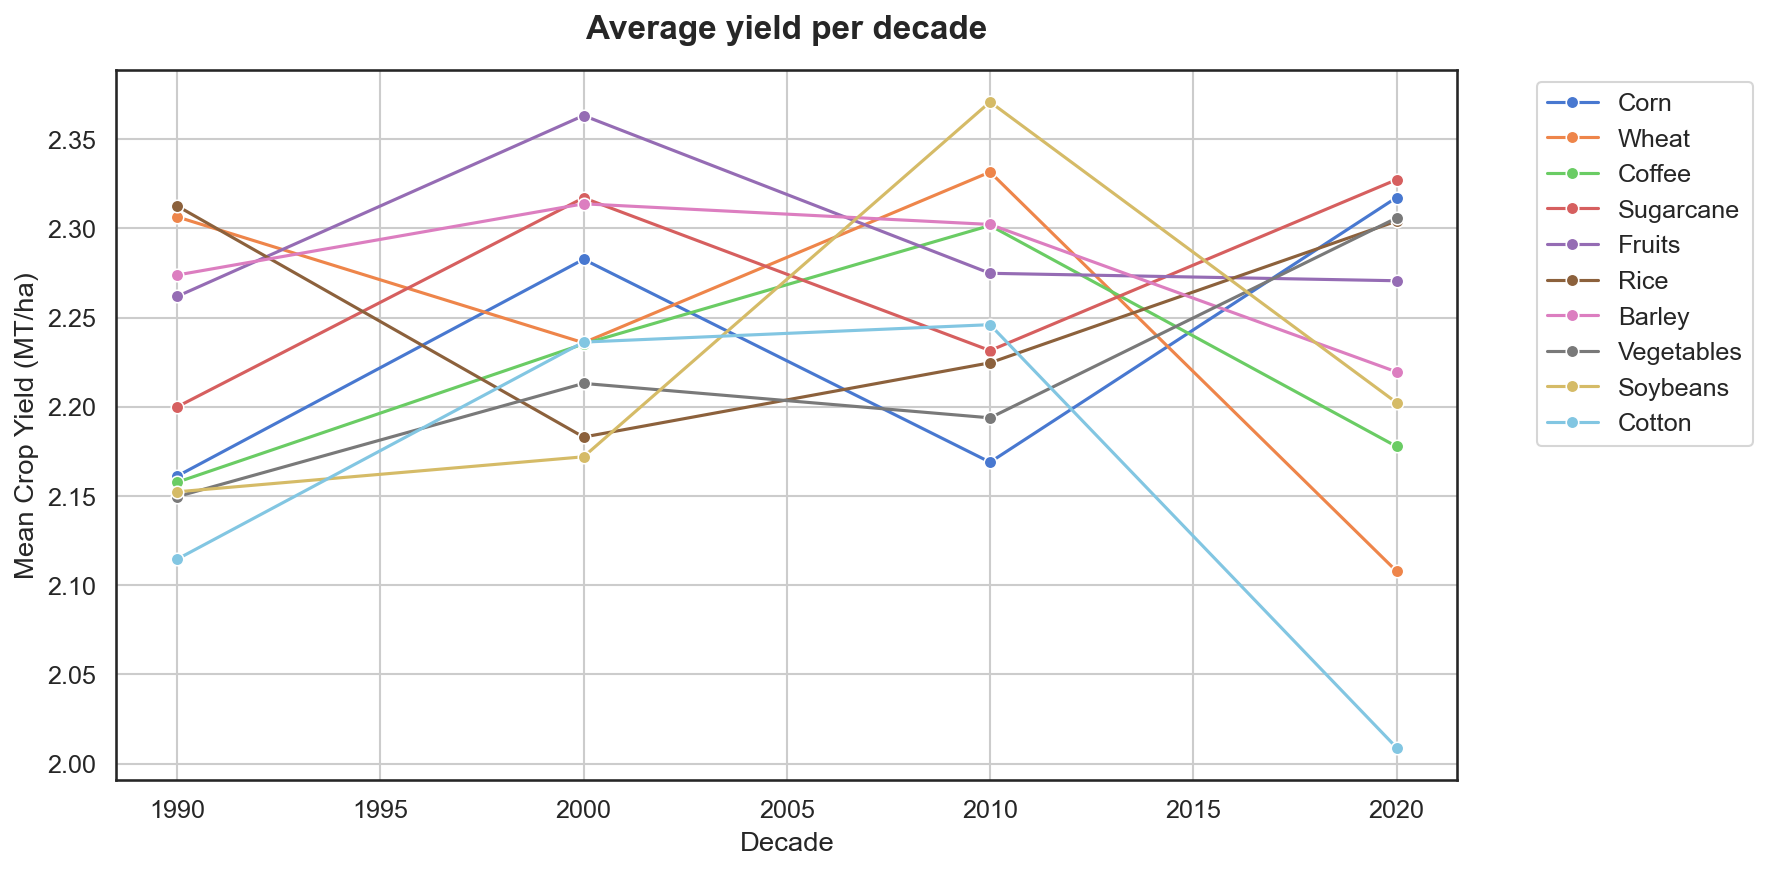

In [50]:
df = df.copy() 
df["Decade"] = (df["Year"] // 10) * 10

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="Decade",
    y="Crop_Yield_MT_per_HA",
    hue="Crop_Type",
    marker="o",
    errorbar=None
)
plt.title("Average yield per decade", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Decade")
plt.ylabel("Mean Crop Yield (MT/ha)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/charts/03_yield_trends.png", dpi=150)
plt.show()


Chart 4 — Adaptation strategy effectiveness
Type: Bar chart
X: Adaptation_Strategies
Y: mean Crop_Yield_MT_per_HA
Sort bars descending
Add value labels on top of bars
Title: "Average Yield by Adaptation Strategy"
Save: outputs/charts/04_adaptation_yield.png

Crop Rotation marginally outperforms other strategies (2.3 vs 2.2) — but difference is negligible

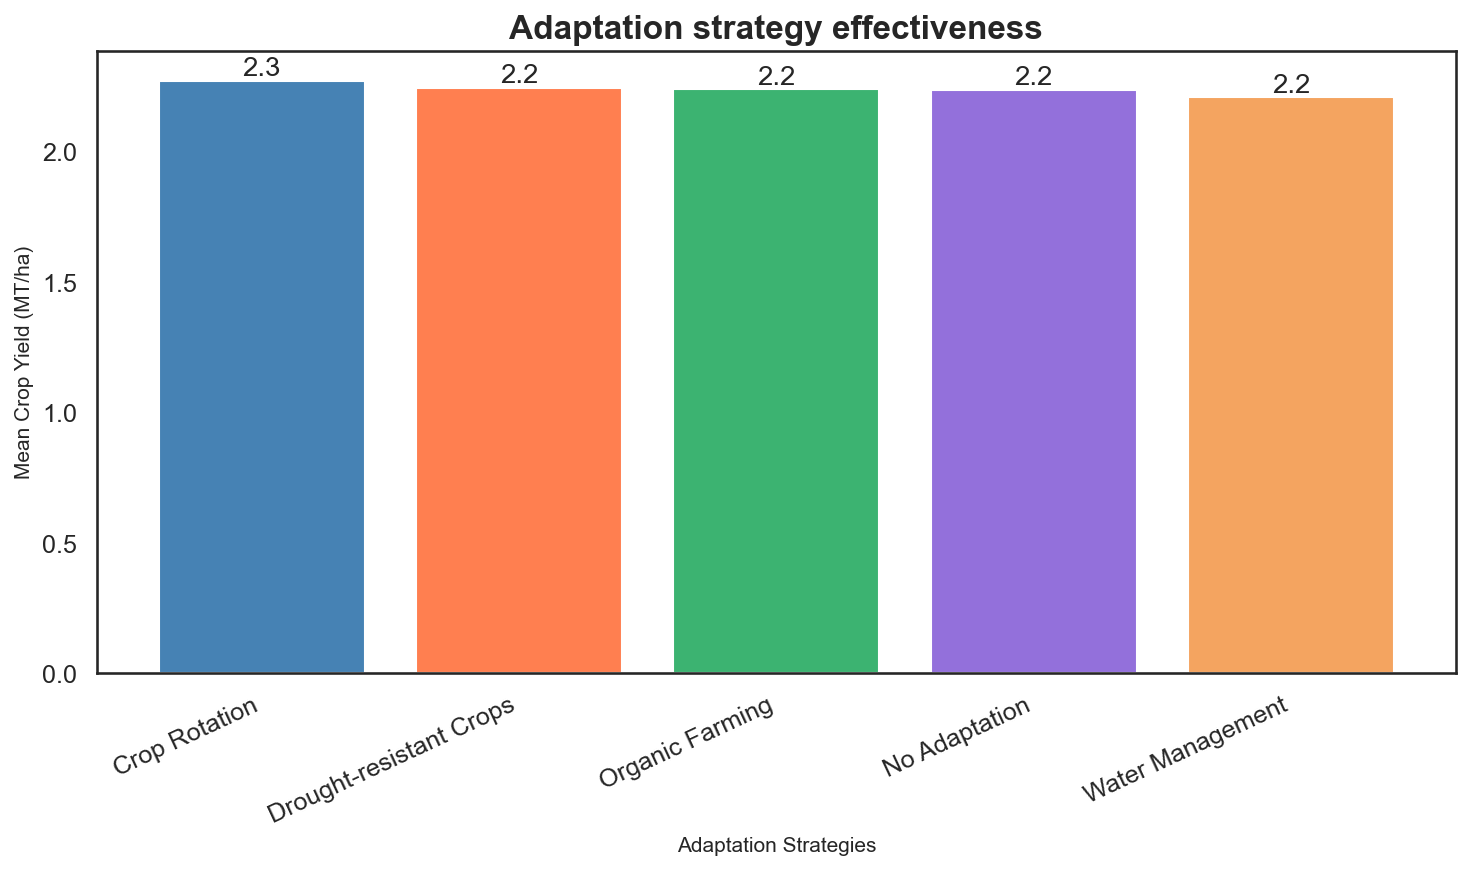

In [28]:
avg_by_strategy = df.groupby("Adaptation_Strategies")["Crop_Yield_MT_per_HA"].mean().reset_index()
avg_by_strategy = avg_by_strategy.sort_values("Crop_Yield_MT_per_HA", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_by_strategy["Adaptation_Strategies"], avg_by_strategy["Crop_Yield_MT_per_HA"], color=["steelblue", "coral", "mediumseagreen", "mediumpurple", "sandybrown"], edgecolor="white")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va = 'bottom')

ax.set_title("Adaptation strategy effectiveness", fontsize=16, fontweight="bold")
ax.set_xlabel("Adaptation Strategies", fontsize=10)
ax.set_ylabel("Mean Crop Yield (MT/ha)", fontsize=10)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig("../outputs/charts/04_adapr_strategies.png", dpi=150)
plt.show()

Chart 5 — Correlation heatmap
Type: Heatmap
Columns: Average_Temperature_C, Total_Precipitation_mm,
         CO2_Emissions_MT, Soil_Health_Index,
         Extreme_Weather_Events, Crop_Yield_MT_per_HA
Title: "Climate Factors Correlation Matrix"
Save: outputs/charts/05_correlation_heatmap.png

Climate factors are almost completely independent of each other and of yield — confirms synthetic data

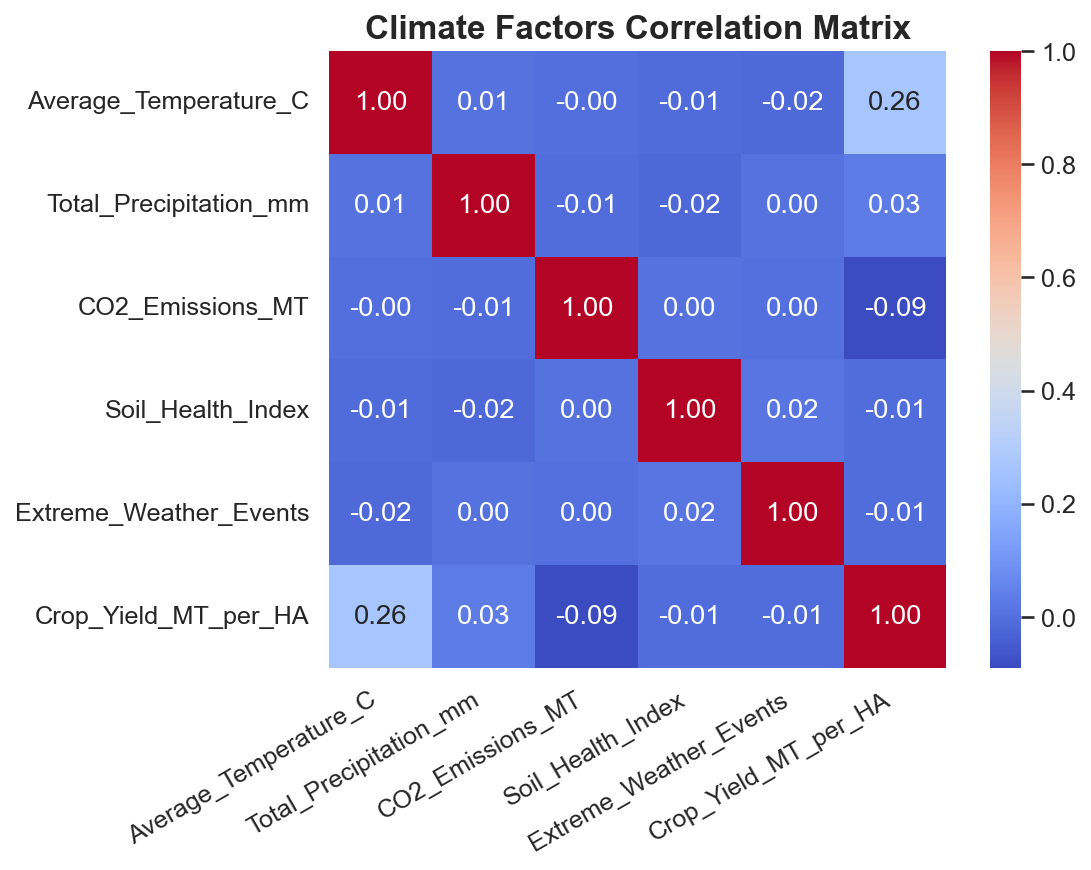

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[["Average_Temperature_C", "Total_Precipitation_mm",
        "CO2_Emissions_MT", "Soil_Health_Index",
        "Extreme_Weather_Events", "Crop_Yield_MT_per_HA"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Climate Factors Correlation Matrix", fontsize=16, fontweight="bold")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("../outputs/charts/05_correlation_heatmap.png", dpi=150)
plt.show()

Chart 6 — Your choice
Pick anything that reveals an interesting pattern.
Could be:
- Yield by country
- Economic impact over time
- Irrigation access vs yield scatter
- CO2 emissions trend by decade

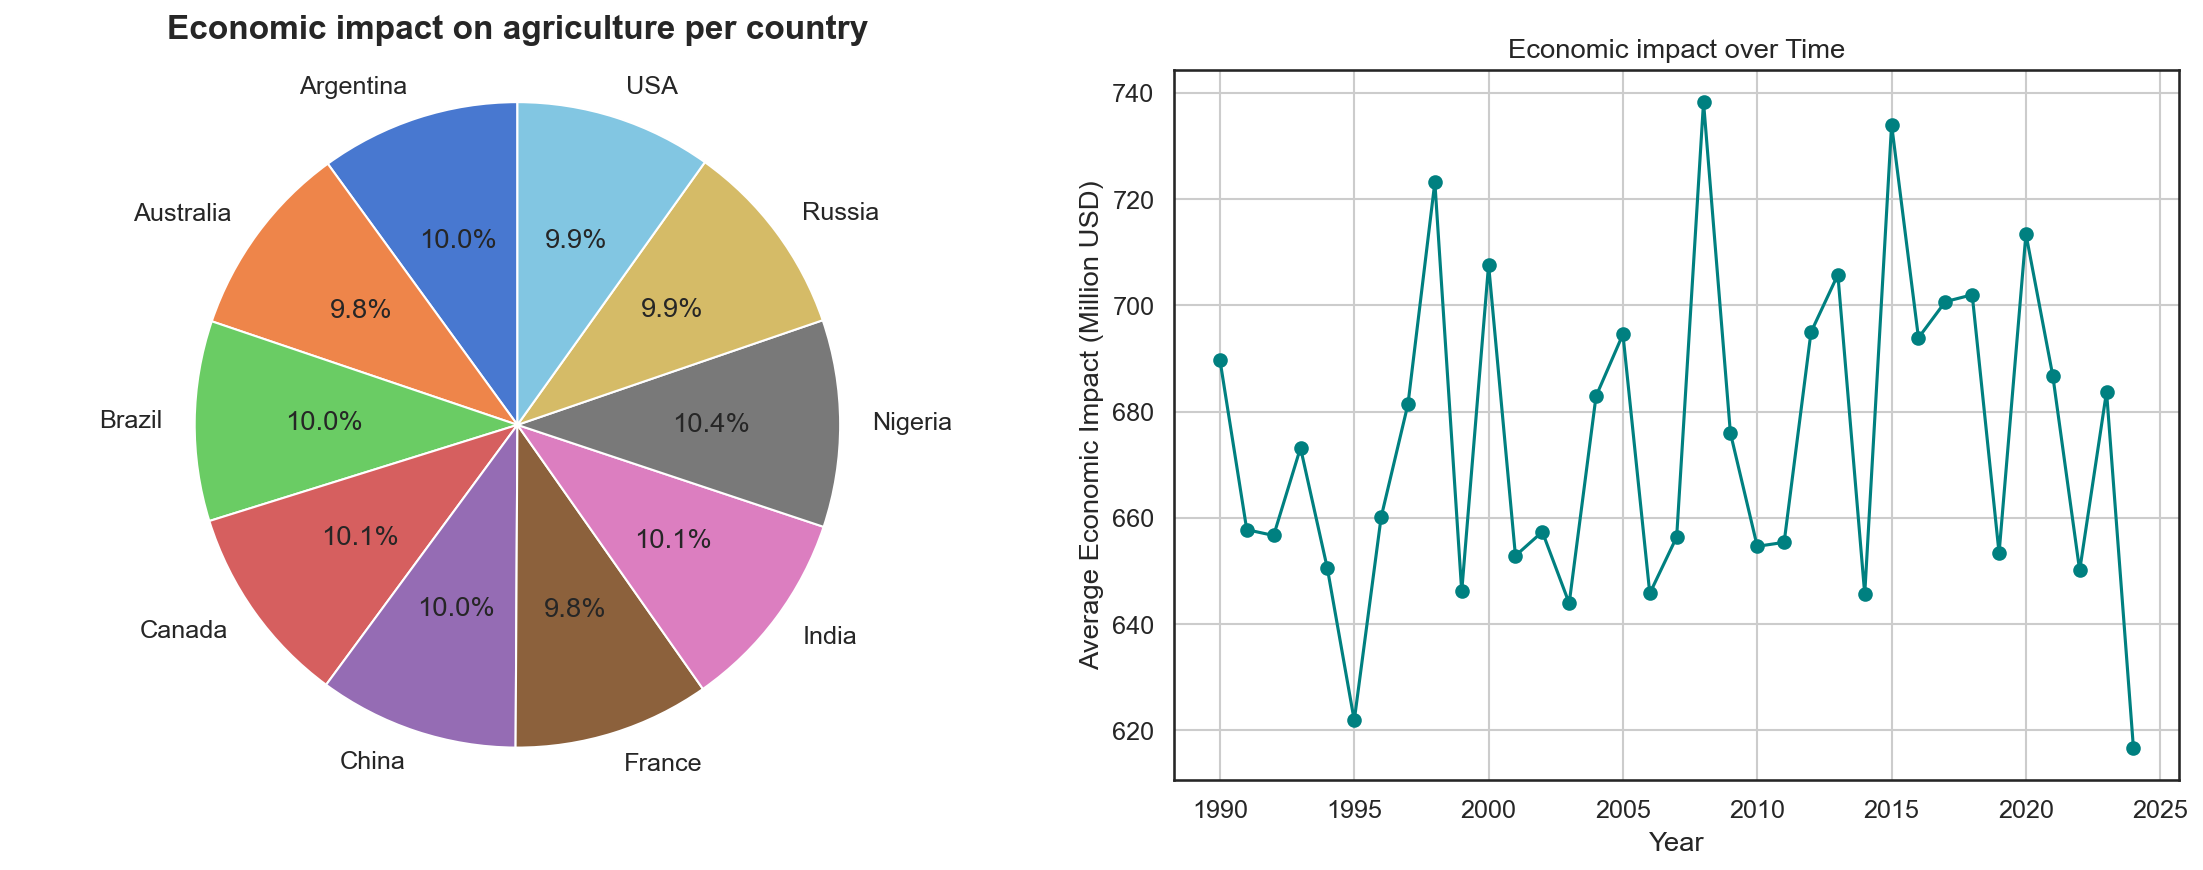

In [49]:
country_avg = df.groupby('Country')['Economic_Impact_Million_USD'].mean()
yearly_economic = df.groupby('Year')['Economic_Impact_Million_USD'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#left pie chart
ax1.pie(country_avg.values, labels = country_avg.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Economic impact on agriculture per country", fontsize=16, fontweight="bold", pad=15)
ax1.axis('equal')

#right line chart
ax2.plot(yearly_economic.index, yearly_economic.values, marker="o", linestyle="-", color="teal")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average Economic Impact (Million USD)")
ax2.set_title("Economic impact over Time")
ax2.grid(True)


plt.tight_layout()
plt.savefig("../outputs/charts/06_economic_two_plots.png", dpi=150)
plt.show()
